In [80]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


In [82]:
# Data
Duration = 1000 # Number of timesteps of the numerical integration
NTrials = 300 # Number of trial x point

angles = np.array([np.pi/6, np.pi/4, np.pi/3])

NPoints = len(angles) # Grid number of points per axis
AntennaeLength = .01 # Sensors distance, on antennae
Positions = np.array([np.cos(angles), np.sin(angles), np.zeros(NPoints)]).T

e3 = np.array([1, 0, 0]) # Source flow axis of symmetry, scheme zxy
dt = .1 # Timesteps 
roll = .2 # Roll Intensity
NameStrategies = ["T"] #"T",

In [83]:
# Integrate numerically the angular dynamics of each strategy
# Calculate the scalar product between t at the end of the evolution
# and the real source position

# tensor gradient in coordinates xyz
def Define_strain_eigenvectors(Grad, e3, AgentPosition):
    G = Grad(e3, AgentPosition)
    assert np.isclose(np.trace(G), 0), "gradient is not trace free"
    #assert np.allclose(G, np.transpose(G)), "gradient is not symmetric"

    # calculations of eigenvectors and relative eigenvalue a
    vaps, veps = np.linalg.eig(G[:-1,:-1])

    i_max = np.argmax(np.abs(vaps))
    s = np.sum(vaps) / vaps[i_max] - 1

    #if np.abs(G[2,2]) > np.max(np.abs(vaps)):
    #    print("Greater eigenvalue is along e_phi")

    # calculation of the trajectories of t as ellipses
    ymax = np.cos(0.5 * np.arccos(s / (2 + s)))
    zmax = np.cos(0.5 * np.arccos((s + 1) / (s - 1)))
    
    n0 = np.array([0,0,1])
    n2 = np.append(veps[:,i_max], 0)
    
    n2 *= np.sign(np.dot(n2, - AgentPosition))
    n1 = np.cross(n2, n0)
    
    return s, ymax, zmax, n0, n1, n2

# tensor gradient in coordinates xyz
def Define_a1a2_strain_eigenvectors(Grad, e3, AgentPosition):
    G = Grad(e3, AgentPosition)
    assert np.isclose(np.trace(G), 0), "gradient is not trace free"
    #assert np.allclose(G, np.transpose(G)), "gradient is not symmetric"
    G_skew = 0.5 * (G - G.T)
    
    # calculations of eigenvectors and relative eigenvalue a
    vaps, veps = np.linalg.eig(G[:-1,:-1])
    
    i_max = np.argmax(np.abs(vaps))
    s = np.sum(vaps) / vaps[i_max] - 1
    lambda_tilde = vaps[1-i_max]/vaps[i_max]
    
    if lambda_tilde > 0:
        lambda_tilde *= -1
        
    omega = 0.0 # G_skew[G_skew != 0][0]/vaps[i_max]
    
    a1 = np.sqrt(lambda_tilde/(lambda_tilde-1))
    a2 = np.sqrt((lambda_tilde + lambda_tilde**2)/(lambda_tilde**2+2*lambda_tilde+omega**2))
    
    return a1, a2


In [84]:
# Information flow 
Grad =  StrainStresslet #, GradientStokeslet, StrainStokeslet] # ShearQuadruplet, GradientQuadruplet
DotProduct_T = np.zeros((NPoints, NTrials))
r1 = np.zeros(NPoints)
t0_T = np.zeros((NPoints, NTrials))
t1_T = np.zeros((NPoints, NTrials))
t2_T = np.zeros((NPoints, NTrials))

for i, AgentPosition in enumerate(Positions):

    # Source position
    OptimalDirection = -AgentPosition/np.linalg.norm(AgentPosition)

    for trials_i in range(NTrials):
        # Random orientation of agent axis
        alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
        RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

        n_T = np.dot(RotationMatrix,[0, 1, 0])
        b_T = np.dot(RotationMatrix,[0, 0, 1])
        t_T = np.dot(RotationMatrix,[1, 0, 0])

        # Time integration of strategies
        for time in range(Duration):
            n_T, b_T, t_T, _ = Evolution_Triangulation(n_T, b_T, t_T, AntennaeLength, 30*AgentPosition, Grad, e3, dt, 0, roll)
           
        t0_T[i, trials_i], t1_T[i, trials_i], t2_T[i, trials_i] = t_T
       
        # Dot product Evaluation
        DotProduct_T[i, trials_i] = np.dot(t_T, OptimalDirection)

    
    
   

In [97]:
# Theoretical P

a2 = np.zeros(len(Positions))
a3 = np.zeros(len(Positions))
P_Theory = np.zeros(len(Positions))
for pos_index, AgentPosition in enumerate(Positions):
    a2[pos_index], a3[pos_index] = Define_a1a2_strain_eigenvectors(Grad, e3, AgentPosition)
    # Theory
    _, ymax, zmax, e_0, e_1, e_2 = Define_strain_eigenvectors(Grad, e3, AgentPosition)
    r1[pos_index] = np.dot(e_2, -AgentPosition/np.linalg.norm(AgentPosition))
    
    P_Theory[pos_index] = r1[pos_index]*np.sqrt(1 - a2[pos_index]*a3[pos_index])

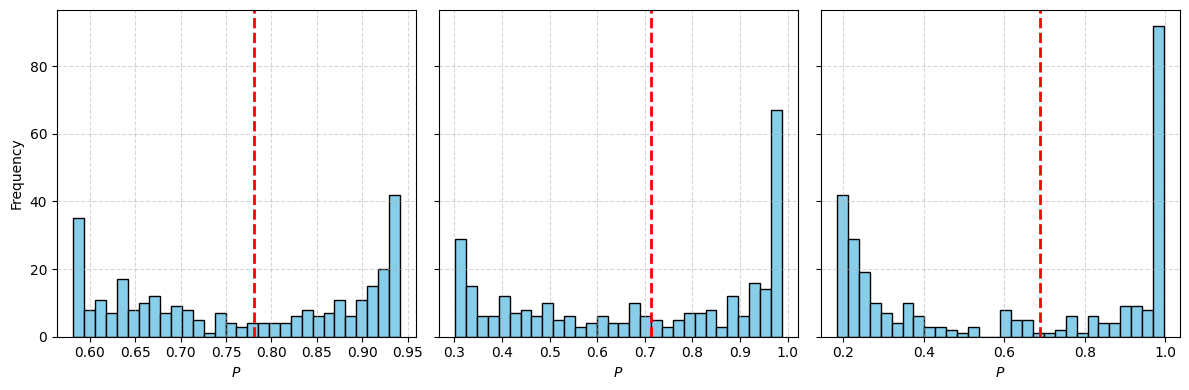

In [98]:
fig, axes = plt.subplots(1, NPoints, figsize=(4*NPoints, 4), sharey=True)  # 1 row, NPoints columns

for i, ax in enumerate(axes):
    ax.hist(DotProduct_T[i], bins=30, color='skyblue', edgecolor='black')
    
    ax.set_xlabel('$P$')
    ax.axvline(x=P_Theory[i], color='red', linestyle='--', linewidth=2, label='x=5')
    if i == 0:
        ax.set_ylabel('Frequency')
        
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Plots_NoNoise/Distribution.png')
plt.show()